In [1]:
import math
from math import gcd, sqrt
from itertools import permutations
from scipy.stats import chi2, kstest, norm, f, expon
from numpy.random import chisquare
import numpy as np
import matplotlib.pyplot as plt

STATISTINIS MODELIAVIMAS

MK užduotis 1-19

1. Sugeneruokite pseudoatsitiktinių skaičių sekas tiesiniu kongruentiniu
metodu su maksimaliu periodu, kai modulis m = 752 ir m = 1026. Daugiklius a parinkite taip, kad galingumai būtų didžiausi. Prieauglio c parinkimui naudokitės gretimų narių koreliacija (teoriniai testai).

Tiesinio kongruentinio metodo formulė

$$
X_{n+1} = (aX_n + c)\pmod{m}  
$$

 Pagal $ \textbf{1 Teorema} $, tiesinės kongruentinės sekos periodo ilgis lygus m tada ir tik tada, kai:

$$
\begin{aligned}
    &\textit{DBD}(c, m) = 1 \\
    &p \mid m \Rightarrow p \mid (a - 1) \\
    &4 \mid m \Rightarrow 4 \mid (a - 1)
\end{aligned}
$$


1.1 seka su $ m = 752 $.

Pirmiausia raskime kandidatus parametrui c Pagal gretimų narių koreliaciją, reikia parinkti
tokį, kad gautume mažą koreliacijos koeficientą, t. y. c jog tenkintų formulę:

$$
\frac{c}{m} \approx \frac{1}{2} \pm \frac{1}{6} \sqrt{3}, \; c \in \mathbb{N}
$$


In [2]:
c_1=(1/2+1/6 * (3**(1/2)))*752
c_2=(1/2-1/6 * (3**(1/2)))*752
c_list=[math.floor(c_1),math.ceil(c_1),math.floor(c_2),math.ceil(c_2)]
print(c_list)

[593, 594, 158, 159]


Kadangi $ c \in \mathbb{N} $, galimos reikšmės: 593, 594, 158, 159.

Reikia tenkinti  $\textit{DBD}(c, 752) = 1 $. Dėl to skaidome 752 pirminiais daugikliais:  $752 = 2^4*47$. Gauname, kad c negali būti lyginis ir dalus iš 47 

In [3]:
final_c=[]
for i in c_list:
    if i%47!=0 and i%2!=0:
        final_c.append(i)
print(final_c)


[593, 159]


Gauname $c=593$.

Primename, kad gautos $p$ reikšmės yra $ 2\: ir\: 47 $ , tad remdamiesi 2 teoremos dalimi gauname:


$$
\begin{aligned}
    &2 \mid 752 \Rightarrow 2 \mid (a - 1) \\
    &47 \mid 752 \Rightarrow 47 \mid (a - 1)
\end{aligned}
$$

Paskutinė sąlyga:

$$ 4 \mid 752 \Rightarrow 4 \mid (a - 1) $$

Ieškome $a$, naudodami kodą:

In [4]:
a_list=[]
for i in range(2,752):
    if (i-1)%2==0 and (i-1)%47==0 and (i-1)%4==0:
        a_list.append(i)
print(a_list)


[189, 377, 565]


Dabar tikrinkime kiekvienos $a$ reikšmės galingumus:


Tiesinės kongruentinės sekos su maksimaliu periodu galingumu vadinsime mažiausią
natūralųjį skaičių $s$, kuriam:

$$ b^s \equiv 0 \pmod{m} $$


Ieškome kiekvieno $a$ galingumo naudodami kodą:

In [5]:
a={}
for i in a_list:
    s=1
    while s<=1000:
        if ((i-1)**s)%752==0:
            a[i]=s
            break
        else:
            s+=1

print(a)

{189: 2, 377: 2, 565: 2}


Su visais $a$ galingumas vienodas. Tokiu atveju renkamės didžiausią $a$, šiuo atveju $a=565$

Gauname seką:

$$
X_{n+1} = (565 * X_n + 593) \pmod{752}  
$$

Fiksuokime $X_{0}=0$. Sugeneruokime atsitiktinę skaičių seką naudodami kodą:

In [6]:
def generator(b):
    return (565 * b + 593) % 752

numbers = [0]

for i in range(0,751):
    numbers.append(generator(numbers[i]))

print(numbers)

[0, 593, 246, 463, 492, 333, 738, 203, 232, 73, 478, 695, 724, 565, 218, 435, 464, 305, 710, 175, 204, 45, 450, 667, 696, 537, 190, 407, 436, 277, 682, 147, 176, 17, 422, 639, 668, 509, 162, 379, 408, 249, 654, 119, 148, 741, 394, 611, 640, 481, 134, 351, 380, 221, 626, 91, 120, 713, 366, 583, 612, 453, 106, 323, 352, 193, 598, 63, 92, 685, 338, 555, 584, 425, 78, 295, 324, 165, 570, 35, 64, 657, 310, 527, 556, 397, 50, 267, 296, 137, 542, 7, 36, 629, 282, 499, 528, 369, 22, 239, 268, 109, 514, 731, 8, 601, 254, 471, 500, 341, 746, 211, 240, 81, 486, 703, 732, 573, 226, 443, 472, 313, 718, 183, 212, 53, 458, 675, 704, 545, 198, 415, 444, 285, 690, 155, 184, 25, 430, 647, 676, 517, 170, 387, 416, 257, 662, 127, 156, 749, 402, 619, 648, 489, 142, 359, 388, 229, 634, 99, 128, 721, 374, 591, 620, 461, 114, 331, 360, 201, 606, 71, 100, 693, 346, 563, 592, 433, 86, 303, 332, 173, 578, 43, 72, 665, 318, 535, 564, 405, 58, 275, 304, 145, 550, 15, 44, 637, 290, 507, 536, 377, 30, 247, 276, 117,

1.2 Seka su $m=1026$.

Sprendžiame taip pat kaip pirmąją seką.

Randame $c$:

In [7]:
c_1=(1/2+1/6 * (3**(1/2)))*1026
c_2=(1/2-1/6 * (3**(1/2)))*1026
c_list=[math.floor(c_1),math.ceil(c_1),math.floor(c_2),math.ceil(c_2)]
print(c_list)

[809, 810, 216, 217]


 $ c \in \mathbb{N} $, galimos reikšmės: 809, 810, 216, 217.

Reikia tenkinti  $\textit{DBD}(c, 1026) = 1 $. Skaidome 752 pirminiais daugikliais:  $1026 = 2*3^3*19$. Gauname, kad c negali būti lyginis, dalus iš $3$ ir dalus iš $19$ 

In [8]:
final_c=[]
for i in c_list:
    if i%19!=0 and i%2!=0 and i%3!=0:
        final_c.append(i)
print(final_c)

[809, 217]


Gauname $c=809$.

Ieškome $a$:

Gautos $p$ reikšmės yra $ 2,\: 3\: ir\: 19 $ , remdamiesi 2 teoremos dalimi gauname:


$$
\begin{aligned}
    &2 \mid 1026 \Rightarrow 2 \mid (a - 1) \\
    &3 \mid 1026 \Rightarrow 3 \mid (a - 1) \\
    &47 \mid 1026 \Rightarrow 19 \mid (a - 1)
\end{aligned}
$$

Taip pat:

$$ 4 \mid 1026 \Rightarrow 4 \mid (a - 1) $$

Ieškome $a$:

In [9]:
a_list=[]
for i in range(2,1026):
    if (i-1)%2==0 and (i-1)%3==0 and (i-1)%19==0 and (i-1)%4==0:
        a_list.append(i)
print(a_list)

[229, 457, 685, 913]


Ieškome visų $a$ galingumo: 

In [10]:
a={}
for i in a_list:
    j=1
    while j<=1000:
        if ((i-1)**j)%1026==0:
            a[i]=j
            break
        else:
            j+=1

print(a)

{229: 3, 457: 3, 685: 2, 913: 3}


Su visais $a$ išskyrus $685$ galingumas vienodas. Renkamės didžiausią $a$, šiuo atveju $a=913$.

Gauname seką:

$$
X_{n+1} = (913 * X_n + 809) \pmod{1026}  
$$

Fiksuokime $X_{0}=0$. Generuojame seką naudodami kodą:

In [11]:
def generator(b):
    return (916 * b + 809) % 1026

numbers_2 = [0]

for i in range(0,1025):
    numbers_2.append(generator(numbers_2[i]))

print(numbers_2)

[0, 809, 55, 915, 707, 1015, 993, 335, 895, 855, 125, 397, 231, 23, 331, 309, 677, 211, 171, 467, 739, 573, 365, 673, 651, 1019, 553, 513, 809, 55, 915, 707, 1015, 993, 335, 895, 855, 125, 397, 231, 23, 331, 309, 677, 211, 171, 467, 739, 573, 365, 673, 651, 1019, 553, 513, 809, 55, 915, 707, 1015, 993, 335, 895, 855, 125, 397, 231, 23, 331, 309, 677, 211, 171, 467, 739, 573, 365, 673, 651, 1019, 553, 513, 809, 55, 915, 707, 1015, 993, 335, 895, 855, 125, 397, 231, 23, 331, 309, 677, 211, 171, 467, 739, 573, 365, 673, 651, 1019, 553, 513, 809, 55, 915, 707, 1015, 993, 335, 895, 855, 125, 397, 231, 23, 331, 309, 677, 211, 171, 467, 739, 573, 365, 673, 651, 1019, 553, 513, 809, 55, 915, 707, 1015, 993, 335, 895, 855, 125, 397, 231, 23, 331, 309, 677, 211, 171, 467, 739, 573, 365, 673, 651, 1019, 553, 513, 809, 55, 915, 707, 1015, 993, 335, 895, 855, 125, 397, 231, 23, 331, 309, 677, 211, 171, 467, 739, 573, 365, 673, 651, 1019, 553, 513, 809, 55, 915, 707, 1015, 993, 335, 895, 855, 125, 3

2. Gautas sekas patikrinkite su dviem testais. Pirma su maksimumo testu, kai maksimumas išrenkamas iš 4 skaičių. Kitą testą pasirinkite patys.

 Tikrinsime ar mūsų duomenys yra iš tolygaus pasiskirstymo. Gautai sekai pritaikome formulę:

$$
U_n=\frac{X_n}{m}
$$

In [12]:
uniformed_numbers=[number/752 for number in numbers]
uniformed_numbers_2=[number/1026 for number in numbers_2]

print(uniformed_numbers)
print(uniformed_numbers_2)

[0.0, 0.788563829787234, 0.3271276595744681, 0.6156914893617021, 0.6542553191489362, 0.4428191489361702, 0.9813829787234043, 0.2699468085106383, 0.30851063829787234, 0.09707446808510638, 0.6356382978723404, 0.9242021276595744, 0.9627659574468085, 0.7513297872340425, 0.2898936170212766, 0.5784574468085106, 0.6170212765957447, 0.40558510638297873, 0.9441489361702128, 0.2327127659574468, 0.2712765957446808, 0.0598404255319149, 0.598404255319149, 0.886968085106383, 0.925531914893617, 0.714095744680851, 0.2526595744680851, 0.5412234042553191, 0.5797872340425532, 0.3683510638297872, 0.9069148936170213, 0.19547872340425532, 0.23404255319148937, 0.022606382978723406, 0.5611702127659575, 0.8497340425531915, 0.8882978723404256, 0.6768617021276596, 0.2154255319148936, 0.5039893617021277, 0.5425531914893617, 0.33111702127659576, 0.8696808510638298, 0.15824468085106383, 0.19680851063829788, 0.9853723404255319, 0.523936170212766, 0.8125, 0.851063829787234, 0.6396276595744681, 0.17819148936170212, 0.

Patikriname ar duomenys tikrai priklauso intervalui [0, 1]

In [13]:
print(np.min(uniformed_numbers), np.max(uniformed_numbers))
print(np.min(uniformed_numbers_2), np.max(uniformed_numbers_2))

0.0 0.9986702127659575
0.0 0.99317738791423


2.1 Pirmas testas

Maksimumo testas suskaido seką į $n$ grupių po $k$ elementų ir kiekvienoje grupėje paima didžiausią reikšmę; jei duomenys tolygiai pasiskirstę intervale [0, 1] , šie maksimumai turėtų pasiskirstyti pagal funkciją:

$$ F(x)=x^k $$

Tolimesniam tikrinimui naudosime KS arba $\omega^2$ kriterijų.

Naudojame maksimumo testą su $k=4$.

2.1.1 pirma seka

Suskirstome seką į grupes po $4$:

In [14]:
n = len(uniformed_numbers) // 4
groups = np.array(uniformed_numbers)[:n * 4].reshape(n, 4)

groups


array([[0.        , 0.78856383, 0.32712766, 0.61569149],
       [0.65425532, 0.44281915, 0.98138298, 0.26994681],
       [0.30851064, 0.09707447, 0.6356383 , 0.92420213],
       [0.96276596, 0.75132979, 0.28989362, 0.57845745],
       [0.61702128, 0.40558511, 0.94414894, 0.23271277],
       [0.2712766 , 0.05984043, 0.59840426, 0.88696809],
       [0.92553191, 0.71409574, 0.25265957, 0.5412234 ],
       [0.57978723, 0.36835106, 0.90691489, 0.19547872],
       [0.23404255, 0.02260638, 0.56117021, 0.84973404],
       [0.88829787, 0.6768617 , 0.21542553, 0.50398936],
       [0.54255319, 0.33111702, 0.86968085, 0.15824468],
       [0.19680851, 0.98537234, 0.52393617, 0.8125    ],
       [0.85106383, 0.63962766, 0.17819149, 0.46675532],
       [0.50531915, 0.29388298, 0.83244681, 0.12101064],
       [0.15957447, 0.9481383 , 0.48670213, 0.77526596],
       [0.81382979, 0.60239362, 0.14095745, 0.42952128],
       [0.46808511, 0.25664894, 0.79521277, 0.0837766 ],
       [0.12234043, 0.91090426,

Randame kiekvienos grupės maksimuma:

In [15]:
V = np.max(groups, axis=1)
V

array([0.78856383, 0.98138298, 0.92420213, 0.96276596, 0.94414894,
       0.88696809, 0.92553191, 0.90691489, 0.84973404, 0.88829787,
       0.86968085, 0.98537234, 0.85106383, 0.83244681, 0.9481383 ,
       0.81382979, 0.79521277, 0.91090426, 0.77659574, 0.75797872,
       0.87367021, 0.7393617 , 0.72074468, 0.83643617, 0.70212766,
       0.97207447, 0.79920213, 0.99202128, 0.93484043, 0.97340426,
       0.95478723, 0.89760638, 0.93617021, 0.91755319, 0.86037234,
       0.89893617, 0.88031915, 0.99601064, 0.86170213, 0.84308511,
       0.9587766 , 0.82446809, 0.80585106, 0.92154255, 0.78723404,
       0.76861702, 0.88430851, 0.75      , 0.73138298, 0.84707447,
       0.71276596, 0.98271277, 0.80984043, 0.67553191, 0.94547872,
       0.98404255, 0.96542553, 0.90824468, 0.94680851, 0.92819149,
       0.87101064, 0.90957447, 0.89095745, 0.8337766 , 0.87234043,
       0.8537234 , 0.96941489, 0.83510638, 0.81648936, 0.93218085,
       0.79787234, 0.77925532, 0.89494681, 0.7606383 , 0.74202

Atliekame KS testą, lygindami su teorine skirstinio funkcija $F(x)=x^4$

In [16]:
D, p_value = kstest(V, lambda x: x**4)

print(D)
print(p_value)
print(p_value < 0.05)

0.220865833750198
1.553636016491898e-08
True


Atliekame $\omega^2$ testą:

In [17]:
def omega_squared_test(V, k):
    n = len(V)
    V_sorted = np.sort(V)
    F_theoretical = V_sorted**k
    i = np.arange(1, n + 1)
    omega2 = 1/(12*n) + np.sum((F_theoretical - (2*i - 1)/(2*n))**2)
    return omega2

omega2_stat = omega_squared_test(V, 4)
print(omega2_stat)


2.855250910715661


Pagal gautus rezultatus galime sakyti, kad duomenys pasiskirste netolygiai.

2.1.2 antra seka

Skirstome seką į grupes po $4$:

In [18]:
n = len(uniformed_numbers_2) // 4
groups_2 = np.array(uniformed_numbers_2)[:n * 4].reshape(n, 4)

groups_2


array([[0.        , 0.78849903, 0.05360624, 0.89181287],
       [0.68908382, 0.98927875, 0.96783626, 0.32651072],
       [0.87231969, 0.83333333, 0.12183236, 0.38693957],
       ...,
       [0.02241715, 0.32261209, 0.30116959, 0.65984405],
       [0.20565302, 0.16666667, 0.45516569, 0.7202729 ],
       [0.55847953, 0.35575049, 0.65594542, 0.63450292]])

Randame grupių maksimumus:

In [19]:
V_2 = np.max(groups_2, axis=1)
V_2

array([0.89181287, 0.98927875, 0.87231969, 0.32261209, 0.65984405,
       0.7202729 , 0.99317739, 0.89181287, 0.98927875, 0.83333333,
       0.65984405, 0.7202729 , 0.65594542, 0.99317739, 0.98927875,
       0.96783626, 0.38693957, 0.65984405, 0.7202729 , 0.99317739,
       0.78849903, 0.98927875, 0.87231969, 0.38693957, 0.65984405,
       0.7202729 , 0.99317739, 0.89181287, 0.98927875, 0.87231969,
       0.32261209, 0.65984405, 0.7202729 , 0.99317739, 0.89181287,
       0.98927875, 0.83333333, 0.65984405, 0.7202729 , 0.65594542,
       0.99317739, 0.98927875, 0.96783626, 0.38693957, 0.65984405,
       0.7202729 , 0.99317739, 0.78849903, 0.98927875, 0.87231969,
       0.38693957, 0.65984405, 0.7202729 , 0.99317739, 0.89181287,
       0.98927875, 0.87231969, 0.32261209, 0.65984405, 0.7202729 ,
       0.99317739, 0.89181287, 0.98927875, 0.83333333, 0.65984405,
       0.7202729 , 0.65594542, 0.99317739, 0.98927875, 0.96783626,
       0.38693957, 0.65984405, 0.7202729 , 0.99317739, 0.78849

Atliekame KS testą:

In [20]:
D, p_value_2 = kstest(V_2, lambda x: x**4)

print(D)
print(p_value_2)
print(p_value_2 < 0.05 )

0.2507685144332563
1.1333201188928164e-14
True


Atliekama $\omega^2$ testą:

In [21]:
def omega_squared_test(V, k):
    n = len(V)
    V_sorted = np.sort(V)
    F_theoretical = V_sorted**k
    i = np.arange(1, n + 1)
    omega2 = 1/(12*n) + np.sum((F_theoretical - (2*i - 1)/(2*n))**2)
    return omega2

omega2_stat = omega_squared_test(V_2, 4)
print(omega2_stat)


2.46626008207075


Pagal gautus duomenis matome, kad seka nėra unikali.

2.2 Antras testas

2 testui atliksime kėlinių testą su k=3

Kėlinių testas (empirinis) suskaido seką į $$n$ grupių po $k$ elementų kiekvienoje iš jų. Iš viso gali būti $k!$ išsidėstymų grupėje. Suskaičiuojama kiek tam tikri išsidėstymai sutinkami tarp $n$
grupių. Mūsų atveju gali būti grupėse $6$ skirtingi išsidėstymai.


Dabar sugrupuosime skaičius po tris, kadangi $k=3$ ir žiūrėsime kiek kokių išsidėstymų (iš šešių galimų) pasitaikė. Galimos kombinacijos, kai $a<b<c$:

<table>
  <thead>
    <tr>
      <th>Nr.</th>
      <th>Tvarka</th>
      <th>Kokia?</th>
      <th>Tvarkos žymėjimas</th>
    </tr>
  </thead>
  <tbody>
    <tr><td>1</td><td>a, b, c</td><td>didėjanti</td><td>T1</td></tr>
    <tr><td>2</td><td>a, c, b</td><td></td><td>T2</td></tr>
    <tr><td>3</td><td>b, a, c</td><td></td><td>T3</td></tr>
    <tr><td>4</td><td>b, c, a</td><td></td><td>T4</td></tr>
    <tr><td>5</td><td>c, a, b</td><td></td><td>T5</td></tr>
    <tr><td>6</td><td>c, b, a</td><td>mažėjanti</td><td>T6</td></tr>
  </tbody>
</table>


2.2.1. Pirmoji seka

Susidarome visas galimas kombinacijas (Čia $a=0,\: b=1, \: c=2$):

In [22]:
grupes = list(permutations([0, 1, 2]))
pasirodymai={key: 0 for key in grupes}

print(pasirodymai)

{(0, 1, 2): 0, (0, 2, 1): 0, (1, 0, 2): 0, (1, 2, 0): 0, (2, 0, 1): 0, (2, 1, 0): 0}


Kadangi elementų skaičius nebūtinai dalus iš $3$ (susidaro nepilnos grupes), tad atmetame iš
galo pakankamai elementų, sugrupuojame elementus po $3$:

In [23]:
n_pilnos_grupes=len(uniformed_numbers)-(len(uniformed_numbers)%3)
po_tris=[uniformed_numbers[i:i+3] for i in range(0,n_pilnos_grupes,3)]
tvarkos=[sorted([0,1,2], key=lambda j:trejetas[j]) for trejetas in po_tris]
len(tvarkos)

250

Susiskaičiuojame kiekvienos grupės pasirodymų skaičių:

In [24]:
for tvarka in tvarkos:
    pasirodymai[tuple(tvarka)]+=1
pasirodymai

{(0, 1, 2): 59,
 (0, 2, 1): 11,
 (1, 0, 2): 26,
 (1, 2, 0): 59,
 (2, 0, 1): 69,
 (2, 1, 0): 26}

Kadangi sekoje yra pilnos 250 grupės, tad teorinis kiekvienos grupės pasirodymų vidurkis yra $\frac{250}{3!}=41.66$, dabar galime skaičiuotis $\chi^2$ statistiką:

In [25]:

pirma_seka_vid = (250/6)
pirmos_vidurkiai=[pirma_seka_vid] * 6
chi2_stat_main_1 = sum((o - e) ** 2 / e for o, e in zip(pasirodymai.values(), pirmos_vidurkiai))
p_value = 1 - chi2.cdf(chi2_stat_main_1, df=5)

print(p_value)

print(p_value < 0.05)

4.963807143099075e-13
True


$p<0.05$, todėl atmetame hipotėzę, kad duomenys pasiskirstę tolygiai.

2.2.2 antroji seka

Sprendžiame identiškai

Susidarome grupes:

In [26]:
grupes = list(permutations([0, 1, 2]))
pasirodymai_2={key: 0 for key in grupes}

Grupuojame elementus:

In [27]:
n_pilnos_grupes_2=len(uniformed_numbers_2)-(len(uniformed_numbers_2)%3)
po_tris_2=[uniformed_numbers_2[i:i+3] for i in range(0,n_pilnos_grupes_2,3)]
tvarkos_2=[sorted([0,1,2], key=lambda j:trejetas[j]) for trejetas in po_tris_2]
len(tvarkos_2)

342

Skaičiuojame kiekvienos grupės pasirodymų skaičių:

In [28]:
for tvarka in tvarkos_2:
    pasirodymai_2[tuple(tvarka)]+=1
pasirodymai_2

{(0, 1, 2): 38,
 (0, 2, 1): 1,
 (1, 0, 2): 114,
 (1, 2, 0): 76,
 (2, 0, 1): 113,
 (2, 1, 0): 0}

Sekoje yra pilnos $342$ grupės, tad teorinis kiekvienos grupės pasirodymų vidurkis yra $\frac{342}{3!}=57$, dabar galime skaičiuotis $\chi^2$ statistiką:

In [29]:
antra_seka_vid = (342/6)
antros_vidurkiai=[antra_seka_vid] * 6
chi2_stat_main_2 = sum((o - e) ** 2 / e for o, e in zip(pasirodymai_2.values(), antros_vidurkiai))
p_value_2 = 1 - chi2.cdf(chi2_stat_main_2, df=5)

print(p_value_2)

print(p_value_2 < 0.05)

0.0
True


$p<0.05$, todėl atmetame hipotėzę, kad duomenys pasiskirstę tolygiai.

Pagal visus turimus rezultatus kaip "geresniąją" seką galime įvardinti seką su $m=752$

In [30]:
geresne = uniformed_numbers

$3.$ Naudodami sugeneruotą geresniąją pseudoatsitiktinių skaičių seką sumodeliuokite du atsitiktinius dydžius, vieną turintį $F$ skirstinį su $2$ ir $4$ laisvės laipsniais, o kitą parinkite patys.

$3.1$ Modeliuosime atsitiktini dydi turintį $F$ skirstynį su $2$ ir $4$ laisvės laipsniais.

Atsitiktinis dydis $X$ turi $F$ pasiskirstymą su $ \nu _1$ ir $\nu _2$ laisvės laipsnių, jei jo pasiskirstymo funkcija:

$$
F(x) = \frac{
\nu_1^{\frac{\nu_1}{2}} \, \nu_2^{\frac{\nu_2}{2}} \, \Gamma\left( \frac{\nu_1 + \nu_2}{2} \right)
}{
\Gamma\left( \frac{\nu_1}{2} \right) \, \Gamma\left( \frac{\nu_2}{2} \right)
}
\int_0^x t^{\frac{\nu_1}{2} - 1} \left( \nu_2 + \nu_1 t \right)^{- \frac{\nu_1}{2} - \frac{\nu_2}{2}} \, dt, \: x\geq0
$$


Taip pasiskirsčiusį atsitiktinį dydį $X$ galima gauti imant:

$$ 
X=\frac{\nu_2 Y_1}{\nu_1 Y_2}

Čia $Y_1$ ir $Y_2$ - nepriklausomi atsitiktiniai dydžiai, turintys $\chi^2$ pasiskirstymą atitinkamai su $\nu_1$ ir $\nu_2$ laisvės laipsnių.

Ieškome $Y_1$ ir $Y_2$

Atsitiktinio dydžio $\chi^2$, su $\nu$ laisvės laipsnių, pasiskirstymo funkcija:

$$
F(x) = \frac{1}{2^{\frac{\nu}{2}} \Gamma\left( \frac{\nu}{2} \right)} \int_0^x t^{\frac{\nu}{2} - 1} e^{-\frac{t}{2}} \, dt, \quad x \geq 0.
$$

Tokį atsitiktinį dydį galima gauti, turint nepriklausomų eksponentiškai pasiskirsčiusių atsitiktinių dydžių rinkinį. Be to, jeigu $\nu$ yra nelyginis skaičius,
reikalingas nepriklausomas nuo eksponentiniu dydžių atsitiktinis dydis, turintis standartinį normalųjį skirstinį. Būtent dydis:


$$
X = \begin{cases}
2(Y_1 + \cdots + Y_k), & \text{kai } \nu = 2k, \\
2(Y_1 + \cdots + Y_k) + Z^2, & \text{kai } \nu = 2k + 1,
\end{cases}
$$


yra pasiskirstęs pagal $\chi^2$ dėsnį su $\nu$ laisvės laipsnių. Čia $Y_1, . . . , Y_k$ - nepriklausomi eksponentiškai pasiskirstę (su vidurkiu, lygiu $1$) atsitiktiniai dydžiai, o $Z \in N(0, 1)$ nepriklauso nuo $Y_i$.


Mūsų $\nu = 2$ ir $\nu = 4$ dėl to naudosime:

$$2(Y_1 + \cdots + Y_k)$$

Turime $k=1$ ir $k=2$. Gausime atsitiktinius dydžius:

$$ 
\begin{aligned}
    & X = 2*Y_1 \: ; \: k = 1 \\
    & X = 2*(Y_1+Y_2) \: ; \: k = 2 
\end{aligned}
$$ 


Čia $Y_1, Y_2, \cdots, Y_k $ žymi nepriklausomai eksponentiškai pasiskirsčiusius atsitiktinius dydžius
su $\mu = 1$. 


Generuokime seką $X$ su $k=1$

In [31]:
def generate_exp(num_1):
    return -np.log(1-num_1)

def generate_normal(num_2):
    return norm.ppf(num_2)

chisq_numbers_1=[]

for i in range(0,len(geresne),2):
    exp=generate_exp(geresne[i])
    normal=generate_normal(geresne[i+1])
    chisq_num=2*exp
    chisq_numbers_1.append(chisq_num)

print(chisq_numbers_1)

[np.float64(-0.0), np.float64(0.7923993093247486), np.float64(2.1241093858686244), np.float64(7.967357988669167), np.float64(0.7378150247487337), np.float64(2.019216435123539), np.float64(6.581063627549271), np.float64(0.68468096997929), np.float64(1.9195516876277878), np.float64(5.770133411332943), np.float64(0.6329220740036483), np.float64(1.8246186131499407), np.float64(5.19476926642938), np.float64(0.5824689481122974), np.float64(1.7339882207258552), np.float64(4.748482163800961), np.float64(0.5332573265078971), np.float64(1.647287338978628), np.float64(4.383839050213053), np.float64(0.4852275741001495), np.float64(1.5641893331528827), np.float64(4.075537690558535), np.float64(0.4383242520300497), np.float64(1.484406675098279), np.float64(3.808474905309491), np.float64(0.3924957329842982), np.float64(1.4076849393533868), np.float64(3.572908833996724), np.float64(0.3476938596059647), np.float64(1.3337979089700178), np.float64(3.362187802681071), np.float64(0.30387364033447595), np.f

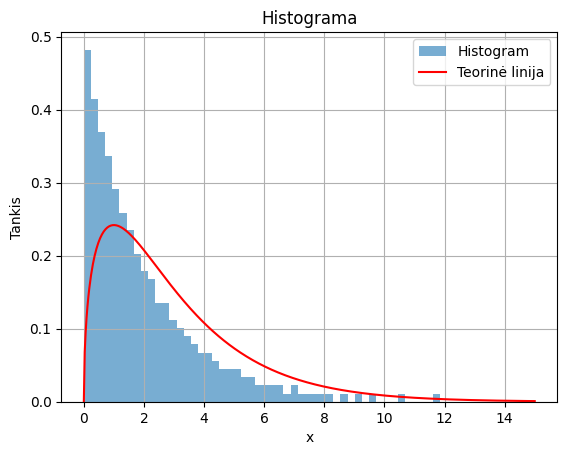

In [32]:
plt.hist(chisq_numbers_1, bins=50, density=True, alpha=0.6, label='Histogram')
x = np.linspace(0, 15, 500)
pdf_chi2 =chi2.pdf(x,df=3)
plt.plot(x, pdf_chi2, label='Teorinė linija', color='red')
plt.title("Histograma")
plt.xlabel("x")
plt.ylabel("Tankis")
plt.legend()
plt.grid(True)
plt.show()

Generuokimę seką $X$ su $k=2$ 

In [33]:
def generate_exp(num_1):
    return -np.log(1-num_1)

def generate_normal(num_2):
    return norm.ppf(num_2)

chisq_numbers_2=[]

for i in range(0,len(geresne),2):
    exp1=generate_exp(geresne[i])
    exp2=generate_exp(geresne[i+1])
    chisq_num=2*(exp1 + exp2)
    chisq_numbers_2.append(chisq_num)

print(chisq_numbers_2)

[np.float64(3.1076642434592165), np.float64(2.705018580999564), np.float64(3.2938401939240283), np.float64(8.596633753549785), np.float64(0.942045417531021), np.float64(7.178586547354118), np.float64(9.364319041739776), np.float64(2.4123500701244085), np.float64(2.95990714630033), np.float64(6.299921526216424), np.float64(0.7563333901101825), np.float64(6.184788748068988), np.float64(7.698965858073734), np.float64(2.140852761949257), np.float64(2.6528312605562525), np.float64(5.183497895638958), np.float64(0.5789889759819035), np.float64(5.437984349453627), np.float64(6.643188811431637), np.float64(1.8875433827121983), np.float64(2.3684816408530835), np.float64(4.420069494169862), np.float64(8.888006354332987), np.float64(4.832359542241623), np.float64(5.849709911449769), np.float64(1.6500455262708396), np.float64(2.1036335447691887), np.float64(3.8308738021930315), np.float64(6.26604321524635), np.float64(4.31947312702355), np.float64(5.206773303799378), np.float64(1.4264324503781216)

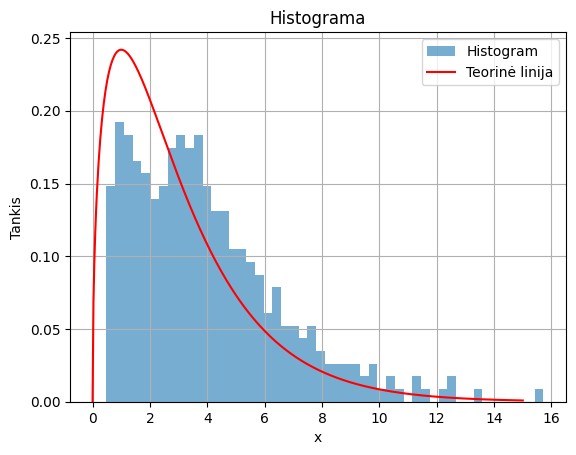

In [34]:
plt.hist(chisq_numbers_2, bins=50, density=True, alpha=0.6, label='Histogram')
x = np.linspace(0, 15, 500)
pdf_chi2 =chi2.pdf(x,df=3)
plt.plot(x, pdf_chi2, label='Teorinė linija', color='red')
plt.title("Histograma")
plt.xlabel("x")
plt.ylabel("Tankis")
plt.legend()
plt.grid(True)
plt.show()

Gautus atsitiktinius dydžius panaudojame $X=\frac{\nu_2 Y_1}{\nu_1 Y_2}$ radimui. 

In [35]:
X_numbers = []
for i in range(0, len(chisq_numbers_2)):
    x_num = (2*chisq_numbers_1[i])/(4*chisq_numbers_2[i])
    X_numbers.append(x_num)

print(X_numbers)

[np.float64(-0.0), np.float64(0.14646836714739675), np.float64(0.32243661817395636), np.float64(0.4633998735481331), np.float64(0.39160268232207496), np.float64(0.14064164454963501), np.float64(0.35139039999680477), np.float64(0.14191161110045275), np.float64(0.32425876771625906), np.float64(0.4579528004691149), np.float64(0.41841473765388326), np.float64(0.14750856395213355), np.float64(0.3373679895580873), np.float64(0.13603666689855787), np.float64(0.3268184159519946), np.float64(0.45803839988012834), np.float64(0.46050732278930673), np.float64(0.1514612063148119), np.float64(0.3299499061858153), np.float64(0.12853415146488692), np.float64(0.3302093007969212), np.float64(0.4610264268394683), np.float64(0.024658187368214613), np.float64(0.15359025566314713), np.float64(0.32552681782177584), np.float64(0.11893481929294164), np.float64(0.334584163399961), np.float64(0.46633079272297717), np.float64(0.027744291545896648), np.float64(0.15439358803108325), np.float64(0.32286673593295157),

Palyginkime gautus duomenis su teorine linija:

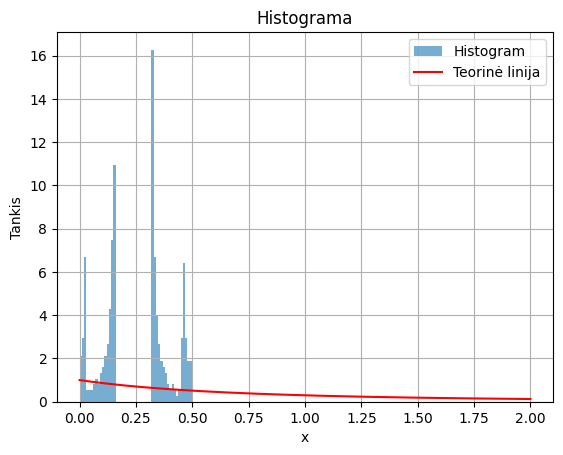

In [36]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import chi2
plt.hist(X_numbers, bins=50, density=True, alpha=0.6, label='Histogram')
x = np.linspace(0, 2, 500)
pdf = f.pdf(x, 2, 4)
plt.plot(x, pdf, label='Teorinė linija', color='red')
plt.title("Histograma")
plt.xlabel("x")
plt.ylabel("Tankis")
plt.legend()
plt.grid(True)
plt.show()

$3.2$ Naudosime Eksponentinį skirstinį su vidurkiu $1$

Jei eksponentiškai pasiskirsčiusio atsitiktinio dydžio $X$ vidurkis $EX=1$, tai jo pasiskirstymo funkcija $F(x) = 1 - e^{-x}$ ir tada a.d. gaunamas pagal:

$$X=-ln(1-U)$$

In [37]:
def generate_exp(num_1):
    return -np.log(1-num_1)
exp_numbers=[generate_exp(number) for number in geresne]

print(exp_numbers)

[np.float64(-0.0), np.float64(1.5538321217296083), np.float64(0.3961996546623743), np.float64(0.9563096358374077), np.float64(1.0620546929343122), np.float64(0.5848654040277019), np.float64(3.9836789943345834), np.float64(0.3146378824403091), np.float64(0.36890751237436686), np.float64(0.10211519639114365), np.float64(1.0096082175617695), np.float64(2.5796850561152893), np.float64(3.2905318137746353), np.float64(1.3916277070952532), np.float64(0.342340484989645), np.float64(0.8638345500725592), np.float64(0.9597758438138939), np.float64(0.520177729336271), np.float64(2.8850667056664716), np.float64(0.26489405744174027), np.float64(0.31646103700182415), np.float64(0.06170565805326711), np.float64(0.9123093065749703), np.float64(2.180085067459524), np.float64(2.59738463321469), np.float64(1.252098295822177), np.float64(0.2912344740561487), np.float64(0.77919190691848), np.float64(0.8669941103629276), np.float64(0.4594215199151986), np.float64(2.3742410819004807), np.float64(0.21750786591

Lyginame rezultata su teorine linija.

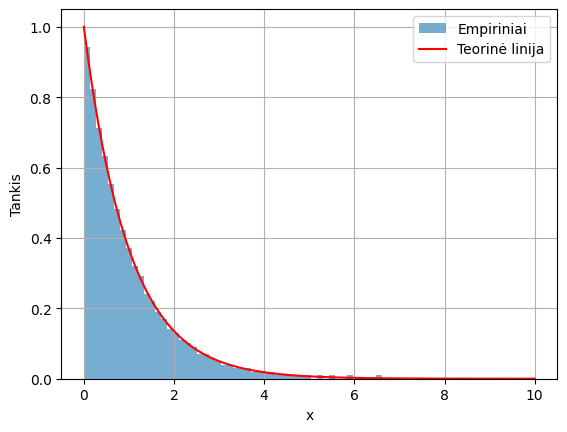

In [38]:
plt.hist(exp_numbers,bins=50, density=True, alpha=0.6, label='Empiriniai')
x = np.linspace(0, 10, 500)
pdf = expon.pdf(x,loc=0,scale=1)
plt.plot(x, pdf,color="red",label="Teorinė linija")
plt.xlabel("x")
plt.ylabel("Tankis")
plt.grid(True)
plt.legend()
plt.show()

$4.$ Naudodami sugeneruotą geresniąją pseudoatsitiktinių skaičių seką ir parinkdami tankius (tolygiai pasiskirsčiusio intervale [0, 1] atsitiktinio dydžio ir kitą savo nuožiūra) suskaičiuokite integralą:

$$
\int_0^1 \tan^2 x \, dx.
$$


Monte karlo metodas:





Turime integralą:

$$ I = \int_a^b g(x) \, dx. $$



Tegul $\xi$ yra atsitiktinis dydis intervale $[a, b]$, turintis tankį $p_\xi(x)$ tokį, kad:

$$\int_a^b p_\xi(x) \, dx = 1; $$


Tada sukonstruojame atsitiktinį dydį: 

$$\eta = \frac{g(\xi)}{p_\xi(\xi)}.$$

Tuomet atsitiktinio dydžio $\eta$ vidurkis:

$$ \mathbb{E}[\eta] = \int_a^b \left( \frac{g(x)}{p_\xi(x)} \right) p_\xi(x) \, dx = I $$


Kai $n$ pakankamai didelis:

$$I \approx \frac{1}{n} \sum_{i=1}^n \eta_i.$$

$4.1$ Tolygus atvejis

Šiuo metu mūsų seka yra tolygiai pasiskirsčiusi intervale (0, 1).

$$ \xi_i = U$$

Kadangi taškai pasiskirstę tolygiai, todėl kiekvienas jų yra vienodai tikėtinas, todėl
galime teigti, kad turime kiekvieną $x$ reikšmę vienodai.

Tolygiai intervale $(0, 1)$ pasiskirsčiusio tankio funkcija yra $1$. 

Apskaičiuokime $ \eta_i = \frac{\tan^2 \xi_i}{1}$ :

Jau turime, kad $\xi_i = U$, tada $\eta_i=\tan^2U$. Gauname:

$$
I \approx \frac{1}{n} \sum_{i=1}^n \tan^2U
$$


Skaičiuojame integralą:

In [39]:
xi_num=[np.tan(num)**2 for num in geresne]
np.mean(xi_num)

np.float64(0.5557965849941984)

Gauname integralo reikšmę $I \approx0.5557965849941984$. Tikroji reikšmė $\approx 0.55741$

$4.2$ Tiesinio skirstinio atvejis

Tarkime mūsų skirstinio tankis yra $ 2x $ Patikrinome, kad $ \int_{0}^{1} \ 2x \, dx = 1.$ Reikia sugeneruoti seką kuri sektų šį skirstinį. Šio skirstinio pasiskirstymo f-ja: $ F(x) = \sqrt u.$ Išsireiškiame a.d. gavimo formulę:


$$ \xi_i = \sqrt U $$

Atliekame skačiavimus :

In [40]:
ties_num = [np.sqrt(u) for u in geresne]

$\eta = \frac{g(\xi)}{p_\xi(\xi)} $ dabar įgyja tokį pavidalą:


$$ \eta_i = \frac{\tan^2 \xi_i}{2\xi_i} $$

Skaičiavimas:

In [41]:
xi_ties = [
(np.tan(xi_i)**2) / (2*xi_i)
for xi_i in ties_num if xi_i > 0.00001
]
np.mean(xi_ties)

np.float64(0.5573377720485746)

Gauname, kad skaičiuojant su tiesiniu skirstiniu, gauname atsakyma šiek tiek artimesni tikrąjam.

$5$ Markovo grandinės generavimas

Sugeneruokite Markovo grandinę. Pradinį skirstinį pasirinkite. Naudokite geresniu algoritmu gautus pseudoatsitiktinius skaičius. Perėjimo matrica:


$$
\begin{pmatrix}
\frac{1}{2} & \frac{1}{2} & 0 & 0 \\
\frac{1}{3} & \frac{1}{3} & \frac{1}{3} & 0 \\
0 & \frac{1}{3} & \frac{1}{3} & \frac{1}{3} \\
0 & 0 & \frac{1}{2} & \frac{1}{2}
\end{pmatrix}
$$


Grandinei generuoti naudosime ``geresniąją'' seką, žymėsime ją $U$. Sugeneruosime Markovo grandinę $(U_1, U_2, \ldots, U_{50})$. Iš perėjimo matricos matome, kad turime 4 būsenas, formalizuokime būsenų aibę $S = \{S_1, S_2, S_3, S_4\}$. Apibrėžiame duomenų atnaujinimo funkciją:


$$
\phi(s_i, x) = 
\begin{cases}
s_1, & \text{kai } x \in [0, P_{i,1}) \\
s_2, & \text{kai } x \in [P_{i,1}, P_{i,1} + P_{i,2}) \\
\vdots & \\
s_j, & \text{kai } x \in \left[ \sum_{\ell=1}^{j-1} P_{i,\ell}, \sum_{\ell=1}^{j} P_{i,\ell} \right) \\
\vdots & \\
s_k, & \text{kai } x \in \left[ \sum_{\ell=1}^{k-1} P_{i,\ell}, 1 \right]
\end{cases}
$$


Mūsų atveju duomenų atnaujinimo funkcija atrodys taip:

$$
\phi(s_1, x) = 
\begin{cases}
s_1, & \text{kai } x \in \left[0, \frac{1}{2} \right), \\
s_2, & \text{kai } x \in \left[ \frac{1}{2}, 1 \right)
\end{cases}
$$


$$
\phi(s_2, x) = 
\begin{cases}
s_1, & \text{kai } x \in \left[0, \frac{1}{3} \right), \\
s_2, & \text{kai } x \in \left[ \frac{1}{3}, \frac{2}{3}\right), \\
s_3, & \text{kai } x \in \left[ \frac{2}{3}, 1 \right)
\end{cases}
$$


$$
\phi(s_3, x) = 
\begin{cases}
s_2, & \text{kai } x \in \left[0, \frac{1}{3} \right), \\
s_3, & \text{kai } x \in \left[ \frac{1}{3}, \frac{2}{3}\right), \\
s_4, & \text{kai } x \in \left[ \frac{2}{3}, 1 \right)
\end{cases}
$$


$$
\phi(s_1, x) = 
\begin{cases}
s_3, & \text{kai } x \in \left[0, \frac{1}{2} \right), \\
s_4, & \text{kai } x \in \left[ \frac{1}{2}, 1 \right)
\end{cases}
$$


Tarkime, kad grandinė startuoja būsenoje $X_0 = S_1 = 1$. Generuokime Markovo grandinę:


In [42]:
def phi(busena, u):
    if busena == 1:
        if u < 1/2:
            return 1
        else:
            return 2
    elif busena == 2:
        if u < 1/3:
            return 1
        elif u < 2/3:
            return 2
        else:
            return 3
    elif busena == 3:
        if u < 1/3:
            return 2
        elif u < 2/3:
            return 3
        else:
            return 4
    elif busena == 4:
        if u < 1/2:
            return 3
        else:
            return 4
m_chain=[1]
for u in geresne:
    last_state = m_chain[-1]
    new_state = phi(last_state, u)
    m_chain.append(new_state)


Gauname tokią Markovo grandinę:

In [43]:
print(m_chain)

[1, 1, 2, 1, 2, 2, 2, 3, 2, 1, 1, 2, 3, 4, 4, 3, 3, 3, 3, 4, 3, 2, 1, 2, 3, 4, 4, 3, 3, 3, 3, 4, 3, 2, 1, 2, 3, 4, 4, 3, 3, 3, 2, 3, 2, 1, 2, 2, 3, 4, 4, 3, 3, 3, 2, 3, 2, 1, 2, 2, 3, 4, 4, 3, 3, 3, 2, 3, 2, 1, 2, 2, 3, 4, 4, 3, 3, 3, 2, 3, 2, 1, 2, 2, 3, 4, 4, 3, 3, 3, 2, 3, 2, 1, 2, 2, 2, 3, 3, 2, 1, 1, 1, 2, 3, 2, 3, 3, 3, 3, 3, 4, 3, 2, 1, 2, 3, 4, 4, 3, 3, 3, 3, 4, 3, 2, 1, 2, 3, 4, 4, 3, 3, 3, 3, 4, 3, 2, 1, 2, 3, 4, 4, 3, 3, 3, 3, 4, 3, 2, 3, 3, 4, 4, 4, 3, 3, 3, 2, 3, 2, 1, 2, 2, 3, 4, 4, 3, 3, 3, 2, 3, 2, 1, 2, 2, 3, 4, 4, 3, 3, 3, 2, 3, 2, 1, 2, 2, 3, 4, 4, 3, 3, 3, 2, 3, 2, 1, 2, 2, 3, 4, 4, 3, 2, 2, 1, 2, 3, 2, 3, 3, 3, 4, 3, 2, 1, 1, 1, 2, 3, 4, 4, 3, 3, 3, 3, 4, 3, 2, 1, 2, 3, 4, 4, 3, 3, 3, 3, 4, 3, 2, 1, 2, 3, 4, 4, 3, 3, 3, 3, 4, 3, 2, 1, 2, 3, 4, 4, 3, 3, 3, 2, 3, 2, 1, 2, 2, 3, 4, 4, 3, 3, 3, 2, 3, 2, 1, 2, 2, 3, 4, 4, 3, 3, 3, 2, 3, 2, 1, 2, 2, 3, 4, 4, 3, 3, 3, 2, 3, 2, 1, 2, 2, 3, 4, 4, 3, 3, 3, 2, 3, 4, 3, 4, 3, 3, 4, 3, 2, 1, 1, 1, 2, 3, 4, 4, 3, 3, 3, 3, 4, 3, 